# Diffusion Model: SU3 gauge theory on $4^4$ lattice

*Sep 24, 2025*

**[Javad Komijani (ETH Zurich)](mailto:jkomijani@gmail.com)**

## Diffusion process on Lie group

Implements a diffusion process as described by the following stochastic     
    differential equation (SDE)                                                 
                                                                                
$$                                                                   
    \frac{d U_t}{dt} = \sigma(t)\, \eta(t)\, U(t)
$$

where $\sigma(t)$ is a time-dependent noise scale, and $\eta(t)$ is standard white Gaussian noise in the algebra space.
We use
$$
    \sigma(t) = \frac{\sigma_0}{\sqrt{1 - t}}
$$                
                                                                                
The reverse process is defined by an SDE that uses a learned score function 
(the gradient of the log-probability density) to iteratively denoise the    
corrupted signal and recover clean samples.
$$                                                                   
    \frac{d U_t}{dt} = \left(-\frac{1 + r^2}{2} \sigma^2(t) s_t(U_t) +  r \sigma(t) \eta(t)\right) U_t
$$
Here $s_t$ is in Lie-algebra element, and $r$ can be time dependent too. As two spatial cases, we can set $r$ to 0 or to 1.

Below, we define a simple neural network for the score function.

In [1]:
import torch
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["text.usetex"] = True

## Data for training and test

We use HMC to generate $256$ samples. For now we use all for training and test.

In [2]:
training_samples = torch.load("../ensembles/cfgs1024_b3_50traj_15steps.pt")

from torch.utils.data import DataLoader, TensorDataset

batch_size = 256 // 4

dataset = TensorDataset(training_samples)

data_loader = DataLoader(
    dataset,
    batch_size = batch_size,
    shuffle = False
)

In [3]:
from lattice_ml.gauge_tools import WilsonGaugeAction

beta = 3

action = WilsonGaugeAction(beta=beta)

## Define a `DiffusionProcess`

A **diffusion process** contains a neural network that models **score function**,
which can be used to perform the reverse process.

Before we continue, let us create a dummy `DiffusionProcess` without any score
function and see the effect of the diffusion process.

In [4]:
from lattice_ml.diffusion.gauge import SUnDiffusionProcess

sigma_0 = 1 / 2

diffusion_process = SUnDiffusionProcess(score_fn=None, sigma_0=sigma_0)

In [5]:
t_eval = torch.linspace(0, 1, 100)

diffused_samples = diffusion_process.forward(training_samples[:64], t_eval=t_eval)

diffused_samples = torch.stack(diffused_samples, dim=0)

In [6]:
from lattice_ml.gauge_tools import compute_mean_reduced_trace_wilson_mxn_loop


def calc_force_sq_mean(x_eval, prefix_dims=2):
    shape = x_eval.shape
    force = action.algebra_force(x_eval.reshape(-1, *shape[2:]))
    force_sq = (force * force.conj()).real
    force_sq_mean = force_sq.reshape(shape[0], -1).mean(dim=1)
    return force_sq_mean / beta ** 2


def plot_wilson_loops(t_eval, x_eval, label=None, axs=None):

    if axs is None:
        fig, axs = plt.subplots(1, 3, figsize=(15, 3))

    w_1x1 = compute_mean_reduced_trace_wilson_mxn_loop(x_eval, 1, 1, prefix_dims=2)
    axs[0].plot(t_eval, w_1x1.mean(dim=1).real, label=label)
    axs[0].set_ylabel(r"$\frac{1}{3}$ ReTr W(1 x 1)")

    w_2x1 = compute_mean_reduced_trace_wilson_mxn_loop(x_eval, 2, 1, prefix_dims=2)
    axs[1].plot(t_eval, w_2x1.mean(dim=1).real, label=label)
    axs[1].set_ylabel(r"$\frac{1}{3}$ ReTr W(2 x 1)")
    
    force_sq_mean = calc_force_sq_mean(x_eval)
    axs[2].plot(t_eval, force_sq_mean, label=label)
    axs[2].set_ylabel(r"$\frac{1}{3}$ Tr $F F^\dagger$")

    for n in range(3):
        axs[n].set_xlabel("Flow time")
        axs[n].grid()
        if label is not None:
            axs[n].legend()

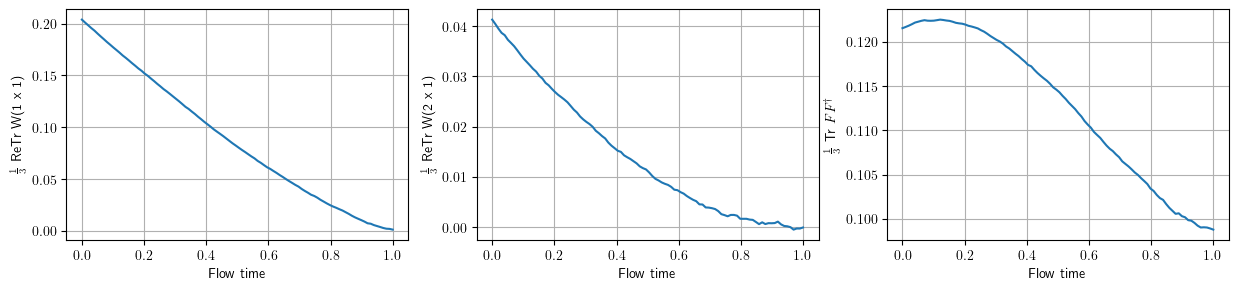

In [7]:
plot_wilson_loops(t_eval, diffused_samples)

### Designing score function

The flow is defined as
The reverse process is defined by an SDE that uses a learned score function 
(the gradient of the log-probability density) to iteratively denoise the    
corrupted signal and recover clean samples.
$$                                                                   
    \frac{d U_t}{dt} = \left(-\frac{1 + r^2}{2} \sigma^2(t) s_t(U_t) +  r \sigma(t) \eta(t)\right) U_t
$$
Here $s_t$ is in Lie-algebra element, and $r$ can be time dependent too. As two spatial cases, we can set $r$ to 0 or to 1.

Below, we define a simple neural network for the score function.

In [8]:
from lattice_ml.gauge_tools import GaugeLinkConv
from lattice_ml.gauge_tools import GaugeLinkSmear
from lattice_ml.gauge_tools import TimeModulatedWeight


sigma_schedule = diffusion_process.sigma_schedule


class GaugeSU3AlgScoreFunc(torch.nn.Module):
    """
    An algebra-element score function for SU(3) matrices.

    This model takes as input the time `t` and the initial state matrix `x` and
    predicts a flow while ensuring the output remains antihermitian and traceless.
    """

    def __init__(self, beta=beta):
        """Initializes the SU3DynamicsFunc neural network."""
        super().__init__()

        self.weight_fn = TimeModulatedWeight(weight_shape=(1,))
        self.layer1 = GaugeLinkSmear()
        self.layer2 = GaugeLinkSmear()
        self.layer3 = GaugeLinkSmear()

    def forward(self, t: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        """
        Computes the algebra-element score function for SU(3) matrices.

        Given a time `t` and a matrix `x`, the function processes the input
        through the neural network and applies post-processing to ensure the
        output is antihermitian and traceless.

        Args:
            - t (torch.Tensor): A 0D or 1D tensor representing time.
              If 1D, it is of shape (batch_size,)
            - x (torch.Tensor): A complex-valued input tensor of shape
              (batch_size, ..., 3, 3).

        Returns:
            - torch.Tensor: A antihermitian, traceless tensor of shape of x:
              (batch_size, ..., 3, 3).
        """

        # Ensure t is a batch tensor
        if t.ndim == 0:
            bsize = x.shape[0]
            t = t.repeat(bsize)

        x = self.layer1(t, x)
        x = self.layer2(t, x)
        x = self.layer3(t, x)

        shape = (-1, *[1]*(x.ndim - 1))

        sigma_t = sigma_schedule(t).reshape(-1, *[1] * (x.ndim - 1))
        weight = self.weight_fn(t).reshape(-1, *[1] * (x.ndim - 1))

        return action.algebra_force(x) * (weight / sigma_t ** 2)

## Training

Now we build the model and train it.

In [9]:
diffusion_process = SUnDiffusionProcess(GaugeSU3AlgScoreFunc(), sigma_0=sigma_0)

# diffusion_process.trainer.action = action

In [10]:
from functools import partial

n_epochs = 100

train_kwargs = dict(
    n_epochs = n_epochs,
    hyperparam = dict(lr=0.01),
    checkpoint_dict = dict(print_every=10),
    scheduler = partial(
        torch.optim.lr_scheduler.CosineAnnealingLR,
        T_max = int(1.01 * n_epochs)              
    )
)

In [11]:
diffusion_process.train(data_loader, loss_c0=0, **train_kwargs)

16:25:38 | Training started for 100 epochs
16:27:43 | Epoch: 10 | loss: 0.8658
16:29:50 | Epoch: 20 | loss: 0.8651
16:32:00 | Epoch: 30 | loss: 0.8664
16:34:08 | Epoch: 40 | loss: 0.8662
16:36:16 | Epoch: 50 | loss: 0.8660
16:38:25 | Epoch: 60 | loss: 0.8666
16:40:34 | Epoch: 70 | loss: 0.8659
16:42:43 | Epoch: 80 | loss: 0.8682
16:44:52 | Epoch: 90 | loss: 0.8659
16:47:00 | Epoch: 100 | loss: 0.8668
16:47:00 | Training finished (cpu); TIME = 1.28e+03 s


Text(0, 0.5, 'Loss')

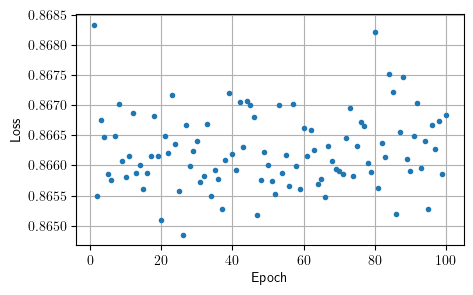

In [12]:
fig, axs = plt.subplots(1, 1, figsize=(5, 3))

loss = diffusion_process.trainer.train_history['loss']
epochs = np.arange(1, len(loss) + 1)
plt.plot(epochs, loss, '.')


plt.grid()
plt.xlabel("Epoch")
plt.ylabel("Loss")

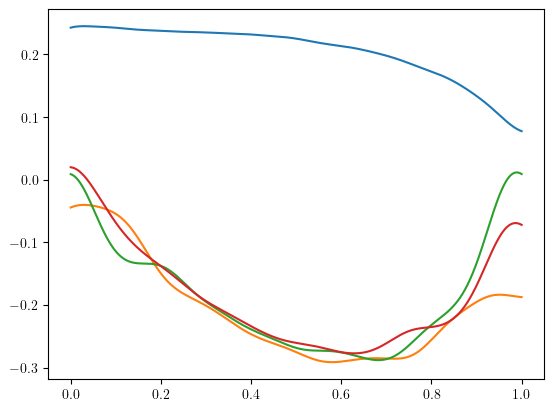

In [13]:
grab = lambda z: z.detach().cpu().numpy()

t = torch.linspace(0, 1, 1001)
tau = diffusion_process.score_fn.weight_fn(t)
tau1 = diffusion_process.score_fn.layer1.weight_fn(t)
tau2 = diffusion_process.score_fn.layer2.weight_fn(t)
tau3 = diffusion_process.score_fn.layer3.weight_fn(t)

plt.plot(t, grab(tau))
plt.plot(t, grab(tau1))
plt.plot(t, grab(tau2))
plt.plot(t, grab(tau3))

In [14]:
num_samples, *sample_shape, n_c, n_c = training_samples.shape

from normflow.prior import SUnPrior
prior = SUnPrior(n_c, sample_shape)

x = prior.sample(32)
t_eval = torch.linspace(1, 0, 100)


with torch.no_grad():
    y_eval = diffusion_process.reverse(x, rev2fwd_noise_ratio=1, step_size=0.01, t_eval=t_eval)


y = y_eval[-1]  # This is the state at the final time of t_eval, i.e. at t = 0

In [15]:
from lattice_ml.gauge_tools import compute_wilson_1x1_loop
from lattice_ml.linalg import eigu


theta_x = eigu(compute_wilson_1x1_loop(x, 0, 1))[0].angle()
theta_y = eigu(compute_wilson_1x1_loop(y, 0, 1))[0].angle()

theta_training = eigu(compute_wilson_1x1_loop(training_samples, 0, 1))[0].angle()

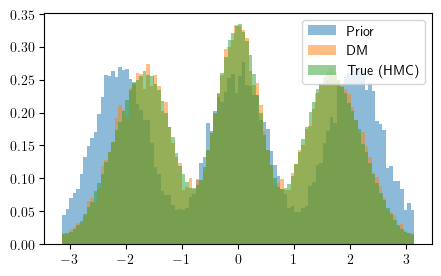

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))

grab = lambda z: z.detach().cpu().numpy()

plt.hist(grab(theta_x).ravel(), label = 'Prior', bins=100, density=True, alpha=0.5)
plt.hist(grab(theta_y).ravel(), label = 'DM', bins=100, density=True, alpha=0.5)
plt.hist(grab(theta_training).ravel(), label = 'True (HMC)', bins=100, density=True, alpha=0.5)

plt.legend();

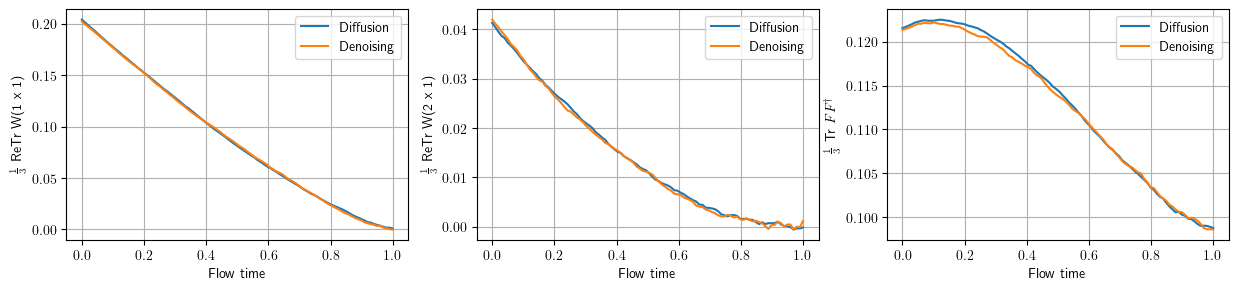

In [17]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3))


t_eval_ = torch.flip(t_eval, dims=(0,))
denoised_samples = torch.flip(torch.stack(y_eval, dim=0), dims=(0,))

plot_wilson_loops(t_eval_, diffused_samples, label='Diffusion', axs=axs)
plot_wilson_loops(t_eval_, denoised_samples, label='Denoising', axs=axs)

for ax in axs:
    ax.grid()

In [18]:
torch.save(diffusion_process.score_fn.state_dict(), "score_fn_state_dict.pt")